# 🔬 Logistic Regression — Under the Hood
> **Goal:** Build logistic regression from scratch. No sklearn, no black boxes.  
> Covers: sigmoid, MLE, gradient descent, p-values, Pseudo-R², VIF,  
> RFE, confusion matrix, ROC/AUC, precision-recall, sensitivity/specificity tradeoff.

---


## 1 · Imports & Synthetic Dataset
We'll simulate a **diabetes screening** dataset — classic binary classification.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Synthetic "diabetes screening" dataset ────────────────────────────────────
n = 800

glucose    = np.random.normal(120, 30, n)
bmi        = np.random.normal(28,  6,  n)
age        = np.random.uniform(20, 80, n)
bp         = np.random.normal(72,  12, n)         # blood pressure (correlated-ish with age)
bp        += 0.15 * age                            # mild correlation to demo VIF
insulin    = np.random.normal(80,  40, n)
skin_fold  = np.random.normal(20,  8,  n)         # correlated with bmi
skin_fold += 0.5 * bmi

# True log-odds (we control the ground truth)
log_odds = (-8
            + 0.04  * glucose
            + 0.08  * bmi
            + 0.02  * age
            + 0.01  * bp
            + 0.003 * insulin
            - 0.01  * skin_fold)

prob    = 1 / (1 + np.exp(-log_odds))
outcome = (np.random.uniform(size=n) < prob).astype(int)

df = pd.DataFrame({
    'glucose':   glucose,
    'bmi':       bmi,
    'age':       age,
    'bp':        bp,
    'insulin':   insulin,
    'skin_fold': skin_fold,
    'diabetes':  outcome
})

print(df.head())
print(f"\nShape: {df.shape}")
print(f"Class balance  →  No diabetes: {(outcome==0).sum()}  |  Diabetes: {(outcome==1).sum()}")


      glucose        bmi        age         bp     insulin  skin_fold  \
0  134.901425  33.629703  68.384217  83.528366  104.408647  31.900266   
1  115.852071  24.903732  47.554393  86.146115   86.278918  26.773554   
2  139.430656  28.576725  23.117395  99.184896   56.538749  42.119479   
3  165.690896  25.226348  67.176692  63.305604   88.968656  21.639229   
4  112.975399  25.393023  32.081827  96.218825  108.584392  45.566758   

   diabetes  
0         1  
1         0  
2         0  
3         1  
4         0  

Shape: (800, 7)
Class balance  →  No diabetes: 283  |  Diabetes: 517


## 2 · Why Not Linear Regression? The Sigmoid Function

Linear regression predicts a continuous value — it can output 1.8 or −0.3, which makes  
no sense for a probability. We need output in $[0, 1]$.

**Solution:** pass the linear combination through the **sigmoid** (logistic) function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad z = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$$

The model is predicting the **log-odds** of the outcome:

$$\log\frac{P(y=1)}{P(y=0)} = X\beta$$


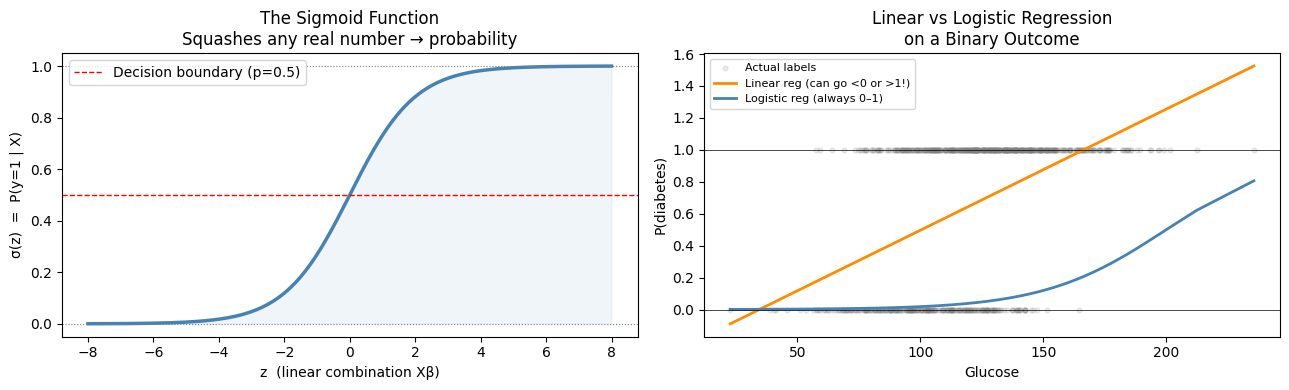

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))   # clip prevents overflow

# ── Visualise the sigmoid ──────────────────────────────────────────────────────
z_range = np.linspace(-8, 8, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(z_range, sigmoid(z_range), color='steelblue', linewidth=2.5)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Decision boundary (p=0.5)')
axes[0].axhline(0,   color='gray', linestyle=':', linewidth=0.8)
axes[0].axhline(1,   color='gray', linestyle=':', linewidth=0.8)
axes[0].fill_between(z_range, sigmoid(z_range), alpha=0.08, color='steelblue')
axes[0].set_xlabel("z  (linear combination Xβ)"); axes[0].set_ylabel("σ(z)  =  P(y=1 | X)")
axes[0].set_title("The Sigmoid Function\nSquashes any real number → probability")
axes[0].legend()

# Linear regression vs logistic for binary outcome (1D example)
x1d = np.sort(glucose)
y1d = outcome[np.argsort(glucose)]
lin_pred = np.polyval(np.polyfit(x1d, y1d, 1), x1d)
log_z    = -8 + 0.04 * x1d
log_pred = sigmoid(log_z)

axes[1].scatter(x1d, y1d, alpha=0.15, s=12, color='gray', label='Actual labels')
axes[1].plot(x1d, lin_pred, color='darkorange',   linewidth=2, label='Linear reg (can go <0 or >1!)')
axes[1].plot(x1d, log_pred, color='steelblue',    linewidth=2, label='Logistic reg (always 0–1)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axhline(1, color='black', linewidth=0.5)
axes[1].set_xlabel("Glucose"); axes[1].set_ylabel("P(diabetes)")
axes[1].set_title("Linear vs Logistic Regression\non a Binary Outcome")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()


## 3 · Train / Test Split & Standardisation

In [4]:
feature_cols = ['glucose', 'bmi', 'age', 'bp', 'insulin', 'skin_fold']
target_col   = 'diabetes'

# ── Manual train-test split ────────────────────────────────────────────────────
def train_test_split_manual(df, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(df))
    n_test = int(len(df) * test_size)
    return df.iloc[idx[n_test:]].reset_index(drop=True), df.iloc[idx[:n_test]].reset_index(drop=True)

train_df, test_df = train_test_split_manual(df)

# ── Standardise using TRAIN statistics only ───────────────────────────────────
mu  = train_df[feature_cols].mean()
sig = train_df[feature_cols].std()

def standardise(d):
    return (d[feature_cols] - mu) / sig

X_train = standardise(train_df).values
X_test  = standardise(test_df).values
y_train = train_df[target_col].values
y_test  = test_df[target_col].values

def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_intercept(X_train)
X_test_b  = add_intercept(X_test)

print(f"Train: {X_train_b.shape}  |  Test: {X_test_b.shape}")
print(f"Train prevalence: {y_train.mean():.2%}  |  Test prevalence: {y_test.mean():.2%}")


Train: (640, 7)  |  Test: (160, 7)
Train prevalence: 65.62%  |  Test prevalence: 60.62%


## 4 · Maximum Likelihood Estimation & Binary Cross-Entropy Loss

Logistic regression is fitted by **Maximum Likelihood Estimation (MLE)**, not least squares.

**Likelihood** — probability of observing our data given parameters β:

$$\mathcal{L}(\beta) = \prod_{i=1}^n p_i^{y_i}(1-p_i)^{1-y_i}$$

Taking the log (easier to work with sums):

$$\ell(\beta) = \sum_{i=1}^n \left[ y_i \log p_i + (1-y_i)\log(1-p_i) \right]$$

We **minimise the negative** log-likelihood (= **Binary Cross-Entropy**):

$$\mathcal{J}(\beta) = -\frac{1}{n}\ell(\beta)$$

**Gradient** (elegant result — same form as linear regression!):

$$\nabla_\beta \mathcal{J} = \frac{1}{n} X^T (\hat{p} - y)$$


Training logistic regression via gradient descent...
  Epoch     0  |  Loss: 0.69315
  Epoch   400  |  Loss: 0.49572
  Epoch   800  |  Loss: 0.49565
  Epoch  1200  |  Loss: 0.49565
  Epoch  1600  |  Loss: 0.49565


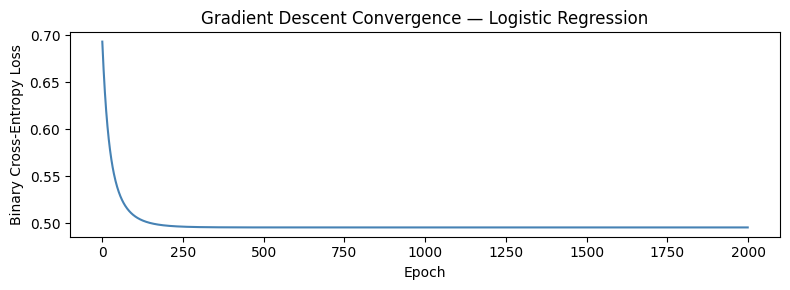

In [5]:
def log_loss(y, p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def gradient(X_b, y, beta):
    p = sigmoid(X_b @ beta)
    return X_b.T @ (p - y) / len(y)

def logistic_fit(X_b, y, lr=0.1, epochs=2000, verbose=False):
    beta = np.zeros(X_b.shape[1])
    history = []
    for epoch in range(epochs):
        p    = sigmoid(X_b @ beta)
        loss = log_loss(y, p)
        beta = beta - lr * gradient(X_b, y, beta)
        history.append(loss)
        if verbose and epoch % 400 == 0:
            print(f"  Epoch {epoch:>5}  |  Loss: {loss:.5f}")
    return beta, history

print("Training logistic regression via gradient descent...")
beta_full, loss_hist = logistic_fit(X_train_b, y_train, lr=0.1, epochs=2000, verbose=True)

plt.figure(figsize=(8, 3))
plt.plot(loss_hist, color='steelblue', linewidth=1.5)
plt.xlabel("Epoch"); plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Gradient Descent Convergence — Logistic Regression")
plt.tight_layout(); plt.show()


## 5 · P-Values for Coefficients

How do we know if a coefficient is **statistically significant** (not just noise)?

**Wald test:** Under the null hypothesis $H_0: \beta_j = 0$, the test statistic:

$$W_j = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)} \sim \mathcal{N}(0,1)$$

The **standard error** comes from the **Fisher Information Matrix** (the Hessian of the log-likelihood):

$$\text{Var}(\hat{\beta}) = \left(X^T W X\right)^{-1}, \quad W_{ii} = \hat{p}_i(1-\hat{p}_i)$$

The p-value is then: $p = 2 \times (1 - \Phi(|W_j|))$  — two-tailed test.

**Interpretation:** p < 0.05 → the feature is unlikely to have zero effect.


In [6]:
def compute_pvalues(X_b, y, beta):
    p_hat = sigmoid(X_b @ beta)
    W     = p_hat * (1 - p_hat)                    # weight per sample
    # Fisher information: XᵀWX
    X_w   = X_b * W[:, np.newaxis]                 # elementwise broadcast
    try:
        cov   = np.linalg.inv(X_w.T @ X_b)        # (XᵀWX)⁻¹
    except np.linalg.LinAlgError:
        cov   = np.linalg.pinv(X_w.T @ X_b)
    se    = np.sqrt(np.diag(cov))
    z_stat = beta / se
    pvals  = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    return se, z_stat, pvals

se, z_stat, pvals = compute_pvalues(X_train_b, y_train, beta_full)

labels = ['intercept'] + feature_cols
print(f"{'Feature':<14} {'Coef':>10} {'SE':>10} {'z-stat':>10} {'p-value':>12} {'Sig':>6}")
print("─" * 68)
for lbl, b, s, z, p in zip(labels, beta_full, se, z_stat, pvals):
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"{lbl:<14} {b:>10.4f} {s:>10.4f} {z:>10.4f} {p:>12.6f} {sig:>6}")

print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05")


Feature              Coef         SE     z-stat      p-value    Sig
────────────────────────────────────────────────────────────────────
intercept          0.9004     0.1045     8.6190     0.000000    ***
glucose            1.3731     0.1292    10.6259     0.000000    ***
bmi                0.4204     0.1083     3.8834     0.000103    ***
age                0.2237     0.1027     2.1776     0.029433      *
bp                 0.0513     0.1029     0.4990     0.617785       
insulin            0.1526     0.0999     1.5268     0.126799       
skin_fold         -0.2521     0.1039    -2.4267     0.015235      *

Significance: *** p<0.001  ** p<0.01  * p<0.05


## 6 · Pseudo R² (McFadden's)

Logistic regression has no true R² (there's no SS_tot for binary outcomes).  
Several **pseudo R²** measures fill this gap.

**McFadden's R²** — most common:

$$R^2_{McFadden} = 1 - \frac{\ell(\hat{\beta})}{\ell(\beta_0)}$$

where:
- $\ell(\hat{\beta})$ = log-likelihood of the **full model**
- $\ell(\beta_0)$ = log-likelihood of the **null model** (intercept only)

**Interpretation:** Not directly comparable to OLS R², but higher is better.  
Values of 0.2–0.4 are considered excellent for logistic regression.

| Pseudo R² | Rough guide |
|-----------|-------------|
| 0.00–0.10 | Poor |
| 0.10–0.20 | Acceptable |
| 0.20–0.40 | Good |
| > 0.40    | Excellent (check for overfitting) |


In [7]:
def null_log_likelihood(y):
    """Log-likelihood when model only knows the base rate."""
    p_null = y.mean()
    return -log_loss(y, np.full(len(y), p_null))   # already negative LL

def full_log_likelihood(X_b, y, beta):
    p = sigmoid(X_b @ beta)
    return -log_loss(y, p)

ll_null = null_log_likelihood(y_train)
ll_full = full_log_likelihood(X_train_b, y_train, beta_full)

mcfadden_r2 = 1 - (ll_full / ll_null)

# Cox-Snell and Nagelkerke for completeness
n_train = len(y_train)
L_null  = np.exp(ll_null * n_train)    # un-logged likelihood
L_full  = np.exp(ll_full * n_train)
cox_snell   = 1 - (L_null / L_full) ** (2/n_train)
nagelkerke  = cox_snell / (1 - L_null ** (2/n_train))

print("Pseudo R² Measures")
print("─" * 40)
print(f"  McFadden's R²  : {mcfadden_r2:.4f}")
print(f"  Cox-Snell R²   : {cox_snell:.4f}")
print(f"  Nagelkerke R²  : {nagelkerke:.4f}")
print(f"\n  Log-Likelihood (null) : {ll_null:.4f}")
print(f"  Log-Likelihood (full) : {ll_full:.4f}")


Pseudo R² Measures
────────────────────────────────────────
  McFadden's R²  : 0.2298
  Cox-Snell R²   : 0.2560
  Nagelkerke R²  : 0.3536

  Log-Likelihood (null) : -0.6435
  Log-Likelihood (full) : -0.4956


## 7 · Variance Inflation Factor (VIF)

Same concept as in linear regression — measures multicollinearity.  
We built-in correlation between `bp` and `age`, and between `skin_fold` and `bmi`, so watch those VIFs.

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ = R² from regressing feature $j$ on all other features (using OLS).


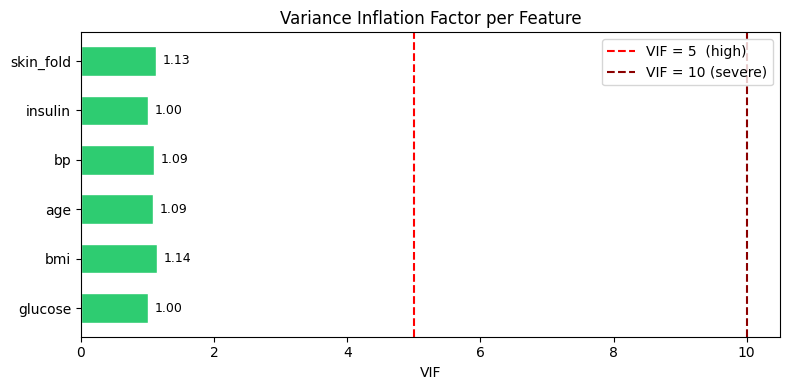


Feature             VIF  Status
──────────────────────────────────────
glucose            1.00  ✅ OK
bmi                1.14  ✅ OK
age                1.09  ✅ OK
bp                 1.09  ✅ OK
insulin            1.00  ✅ OK
skin_fold          1.13  ✅ OK


In [8]:
def ols_r2(X_b, y):
    beta_ols = np.linalg.lstsq(X_b, y, rcond=None)[0]
    y_hat    = X_b @ beta_ols
    ss_res   = np.sum((y - y_hat)**2)
    ss_tot   = np.sum((y - y.mean())**2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0

def compute_vif(X):
    """X: 2D array of features (no intercept)."""
    n_feat = X.shape[1]
    vifs   = []
    for j in range(n_feat):
        X_others = np.delete(X, j, axis=1)
        X_others_b = np.hstack([np.ones((X_others.shape[0], 1)), X_others])
        r2 = ols_r2(X_others_b, X[:, j])
        r2 = min(r2, 0.9999)
        vifs.append(1 / (1 - r2))
    return vifs

vif_vals = compute_vif(X_train)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors_vif = ['#e74c3c' if v > 5 else '#f39c12' if v > 2.5 else '#2ecc71' for v in vif_vals]
bars = ax.barh(feature_cols, vif_vals, color=colors_vif, edgecolor='white', height=0.6)
ax.axvline(5,  color='red',    linestyle='--', linewidth=1.5, label='VIF = 5  (high)')
ax.axvline(10, color='darkred',linestyle='--', linewidth=1.5, label='VIF = 10 (severe)')
for bar, v in zip(bars, vif_vals):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=9)
ax.set_xlabel("VIF"); ax.set_title("Variance Inflation Factor per Feature")
ax.legend(); plt.tight_layout(); plt.show()

print(f"\n{'Feature':<14} {'VIF':>8}  {'Status'}")
print("─" * 38)
for feat, v in zip(feature_cols, vif_vals):
    status = '⚠️  HIGH' if v > 5 else ('🔶 Moderate' if v > 2.5 else '✅ OK')
    print(f"{feat:<14} {v:>8.2f}  {status}")


## 8 · Recursive Feature Elimination (RFE)

**Problem:** We have 6 features. Which ones actually matter?

**RFE algorithm:**
1. Train model on all features
2. Remove the least important feature (smallest |coefficient|)
3. Retrain on remaining features
4. Repeat until desired number of features remain

We rank features by elimination order — last to be eliminated = most important.


Running RFE... (this trains multiple models)

Elimination Order (first = least important):
  1. bp              Eliminated 1st 🔴
  2. insulin         Eliminated 2nd 🟠
  3. age             Rank #3
  4. skin_fold       Rank #4
  5. bmi             Rank #5
  6. glucose         Most Important ⭐


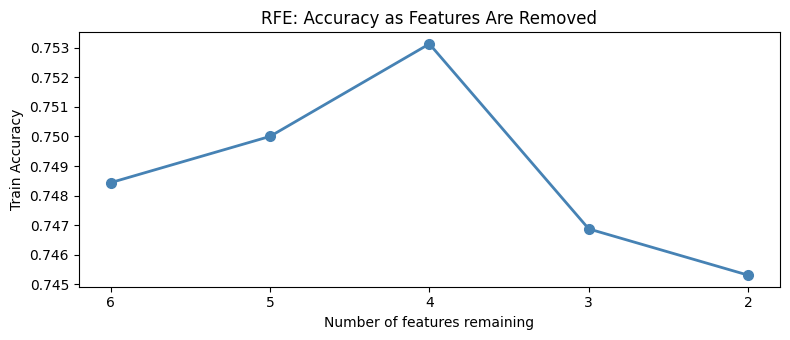

In [9]:
def rfe_logistic(X_b, y, feature_names, lr=0.1, epochs=1500):
    """
    Recursive Feature Elimination for logistic regression.
    Returns elimination order (first eliminated = least important).
    """
    remaining = list(range(len(feature_names)))   # indices into feature_names
    elim_order = []
    scores_history = []

    # Working copies (intercept col 0 is always kept)
    X_work = X_b.copy()
    feat_idx_in_Xwork = list(range(1, len(feature_names) + 1))  # cols in X_work

    while len(remaining) > 1:
        beta, _ = logistic_fit(X_work, y, lr=lr, epochs=epochs)

        # Accuracy on train as proxy score
        preds  = (sigmoid(X_work @ beta) >= 0.5).astype(int)
        acc    = (preds == y).mean()
        scores_history.append((list(remaining), acc))

        # Feature importances = |coef| (skip intercept at index 0)
        coef_magnitudes = np.abs(beta[1:])
        worst_local_idx = np.argmin(coef_magnitudes)       # local index in beta[1:]
        worst_feat_idx  = remaining[worst_local_idx]       # original feature index

        elim_order.append(feature_names[worst_feat_idx])

        # Drop that column from X_work
        col_to_drop = worst_local_idx + 1                  # +1 for intercept
        X_work = np.delete(X_work, col_to_drop, axis=1)
        remaining.pop(worst_local_idx)

    elim_order.append(feature_names[remaining[0]])         # last surviving feature
    return elim_order, scores_history

print("Running RFE... (this trains multiple models)")
elim_order, rfe_scores = rfe_logistic(X_train_b, y_train, feature_cols)

print("\nElimination Order (first = least important):")
for rank, feat in enumerate(elim_order, 1):
    importance = "Eliminated 1st 🔴" if rank == 1 else (
                 "Eliminated 2nd 🟠" if rank == 2 else (
                 f"Rank #{rank}" if rank < len(elim_order) else "Most Important ⭐"))
    print(f"  {rank}. {feat:<14}  {importance}")

# ── Plot accuracy as features are removed ─────────────────────────────────────
n_feats = [len(s[0]) for s in rfe_scores]
accs    = [s[1]      for s in rfe_scores]

plt.figure(figsize=(8, 3.5))
plt.plot(n_feats, accs, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.gca().invert_xaxis()
plt.xticks(n_feats)
plt.xlabel("Number of features remaining")
plt.ylabel("Train Accuracy")
plt.title("RFE: Accuracy as Features Are Removed")
plt.tight_layout(); plt.show()


## 9 · Predictions & Confusion Matrix

The model outputs **probabilities**. We need a **threshold** to convert them to class labels.  
Default: predict 1 if $\hat{p} \geq 0.5$.

The **confusion matrix** lays out all four outcomes:

|  | Predicted 0 | Predicted 1 |
|--|--|--|
| **Actual 0** | True Negative (TN) | False Positive (FP) |
| **Actual 1** | False Negative (FN) | True Positive (TP) |


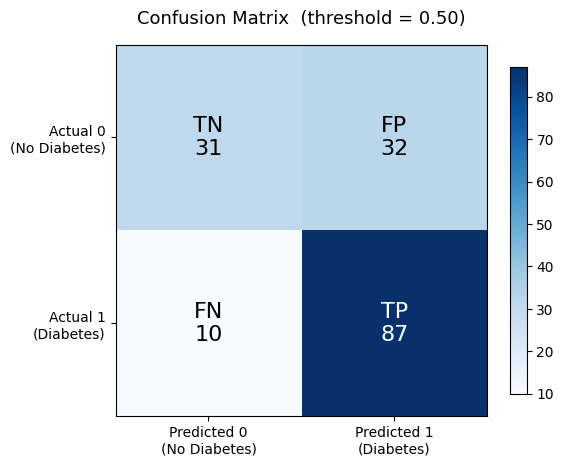

TN=31  FP=32  FN=10  TP=87


In [ ]:
def predict_proba(X_b, beta):
    return sigmoid(X_b @ beta)

def predict_class(X_b, beta, threshold=0.5):
    return (predict_proba(X_b, beta) >= threshold).astype(int)

def confusion_matrix_manual(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[TN, Ffffffffffffffffffffffffffffffffffffffffffffffff......,,,          rrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrP], [FN, TP]])

y_pred_prob  = predict_proba(X_test_b, beta_full)
y_pred_class = predict_class(X_test_b, beta_full, threshold=0.5)
cm = confusion_matrix_manual(y_test, y_pred_class)

# ── Pretty plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
labels_cm = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels_cm[i][j]}\n{cm[i,j]}",
                ha='center', va='center', fontsize=16,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Predicted 0\n(No Diabetes)', 'Predicted 1\n(Diabetes)'], fontsize=10)
ax.set_yticklabels(['Actual 0\n(No Diabetes)', 'Actual 1\n(Diabetes)'], fontsize=10)
ax.set_title("Confusion Matrix  (threshold = 0.50)", fontsize=13, pad=15)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print(f"TN={TN}  FP={FP}  FN={FN}  TP={TP}")


## 10 · Classification Metrics — Full Glossary

$$\text{Accuracy}    = \frac{TP+TN}{TP+TN+FP+FN}$$

$$\text{Sensitivity (Recall / TPR)} = \frac{TP}{TP+FN} \quad \leftarrow \text{of all actual positives, how many did we catch?}$$

$$\text{Specificity (TNR)} = \frac{TN}{TN+FP} \quad \leftarrow \text{of all actual negatives, how many did we correctly reject?}$$

$$\text{Precision (PPV)} = \frac{TP}{TP+FP} \quad \leftarrow \text{of all predicted positives, how many were truly positive?}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} \quad \leftarrow \text{harmonic mean of precision and recall}$$

$$\text{False Positive Rate (FPR)} = 1 - \text{Specificity} = \frac{FP}{TN+FP}$$


In [11]:
def classification_metrics(y_true, y_pred, threshold=0.5):
    cm = confusion_matrix_manual(y_true, y_pred)
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0   # recall / TPR
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0   # TNR
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0   # PPV
    fpr         = FP / (FP + TN) if (FP + TN) > 0 else 0   # 1 - specificity
    f1          = (2 * precision * sensitivity / (precision + sensitivity)
                   if (precision + sensitivity) > 0 else 0)

    return dict(accuracy=accuracy, sensitivity=sensitivity, specificity=specificity,
                precision=precision, f1=f1, fpr=fpr, TP=TP, TN=TN, FP=FP, FN=FN)

metrics = classification_metrics(y_test, y_pred_class)

print(f"{'Metric':<22} {'Value':>8}   Meaning")
print("─" * 65)
rows = [
    ("Accuracy",         metrics['accuracy'],    "Overall % correct"),
    ("Sensitivity/Recall",metrics['sensitivity'],"% of sick caught (True Positive Rate)"),
    ("Specificity",      metrics['specificity'], "% of healthy correctly excluded"),
    ("Precision (PPV)",  metrics['precision'],   "% of positive predictions that are correct"),
    ("F1 Score",         metrics['f1'],          "Balance of precision & recall"),
    ("False Positive Rate",metrics['fpr'],       "% of healthy wrongly flagged as sick"),
]
for name, val, meaning in rows:
    print(f"  {name:<20} {val:>8.4f}   {meaning}")


Metric                    Value   Meaning
─────────────────────────────────────────────────────────────────
  Accuracy               0.7375   Overall % correct
  Sensitivity/Recall     0.8969   % of sick caught (True Positive Rate)
  Specificity            0.4921   % of healthy correctly excluded
  Precision (PPV)        0.7311   % of positive predictions that are correct
  F1 Score               0.8056   Balance of precision & recall
  False Positive Rate    0.5079   % of healthy wrongly flagged as sick


## 11 · Sensitivity / Specificity Tradeoff

Changing the **threshold** shifts the balance between catching positives (sensitivity)  
and avoiding false alarms (specificity). They always trade off — you can't maximise both.

**Medical intuition:**
- **Screening test** (don't miss sick people) → lower threshold → higher sensitivity, lower specificity
- **Confirmatory test** (don't treat healthy people) → higher threshold → lower sensitivity, higher specificity

The **Youden Index** finds the threshold that maximises `Sensitivity + Specificity − 1`.


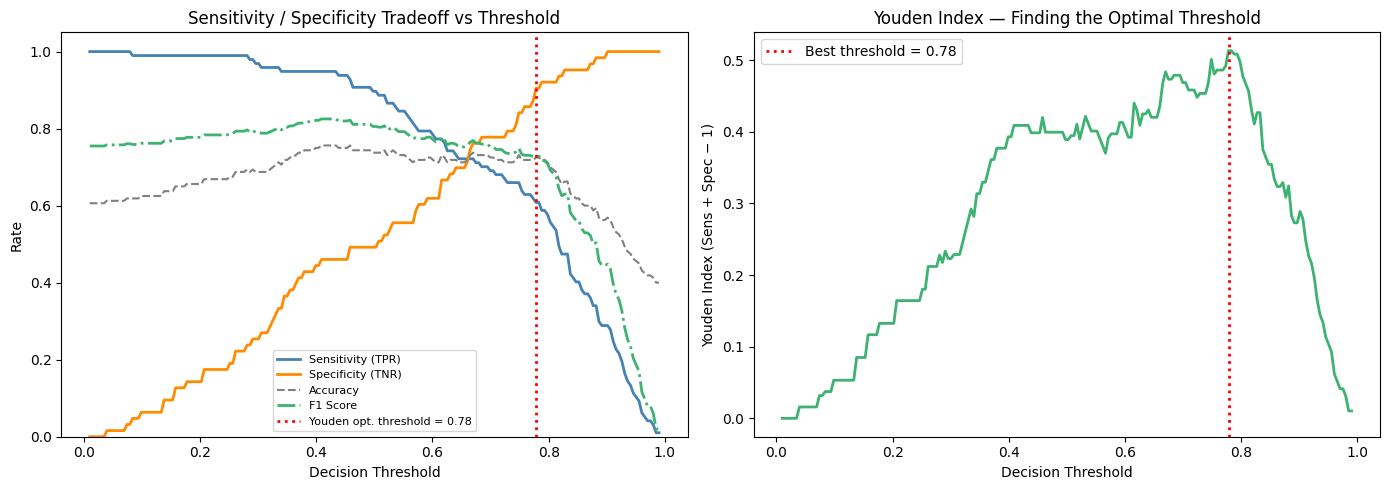

Youden-optimal threshold : 0.778
F1-optimal threshold     : 0.409


In [16]:
thresholds = np.linspace(0.01, 0.99, 200)
sens_list, spec_list, f1_list, acc_list = [], [], [], []

for t in thresholds:
    yp = (y_pred_prob >= t).astype(int)
    m  = classification_metrics(y_test, yp, t)
    sens_list.append(m['sensitivity'])
    spec_list.append(m['specificity'])
    f1_list.append(m['f1'])
    acc_list.append(m['accuracy'])

youden    = np.array(sens_list) + np.array(spec_list) - 1
best_t_youden = thresholds[np.argmax(youden)]
best_t_f1     = thresholds[np.argmax(f1_list)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Sens & Spec vs threshold
axes[0].plot(thresholds, sens_list, color='steelblue',    linewidth=2, label='Sensitivity (TPR)')
axes[0].plot(thresholds, spec_list, color='darkorange',   linewidth=2, label='Specificity (TNR)')
axes[0].plot(thresholds, acc_list,  color='gray',         linewidth=1.5, linestyle='--', label='Accuracy')
axes[0].plot(thresholds, f1_list, color='mediumseagreen', linewidth=2, linestyle='-.', label='F1 Score')
axes[0].axvline(best_t_youden, color='red', linestyle=':', linewidth=2,
                label=f'Youden opt. threshold = {best_t_youden:.2f}')
axes[0].set_xlabel("Decision Threshold"); axes[0].set_ylabel("Rate")
axes[0].set_title("Sensitivity / Specificity Tradeoff vs Threshold")
axes[0].legend(fontsize=8); axes[0].set_ylim(0, 1.05)

# Right: Youden index
axes[1].plot(thresholds, youden, color='mediumseagreen', linewidth=2)
axes[1].axvline(best_t_youden, color='red', linestyle=':', linewidth=2,
                label=f'Best threshold = {best_t_youden:.2f}')
axes[1].set_xlabel("Decision Threshold"); axes[1].set_ylabel("Youden Index (Sens + Spec − 1)")
axes[1].set_title("Youden Index — Finding the Optimal Threshold")
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Youden-optimal threshold : {best_t_youden:.3f}")
print(f"F1-optimal threshold     : {best_t_f1:.3f}")


## 12 · ROC Curve & AUC — Comparing Two Models

**ROC curve** plots **TPR (Sensitivity)** vs **FPR (1 − Specificity)** across all thresholds.

**AUC** (Area Under the Curve) = probability that the model ranks a random positive  
higher than a random negative. **AUC = 1.0** is perfect; **AUC = 0.5** is random guessing.

To demonstrate the comparison, we'll train:
- **Full model** — all 6 features
- **Reduced model** — only `glucose` and `bmi` (weaker model on purpose)

AUC lets us compare models **without choosing a threshold** first.


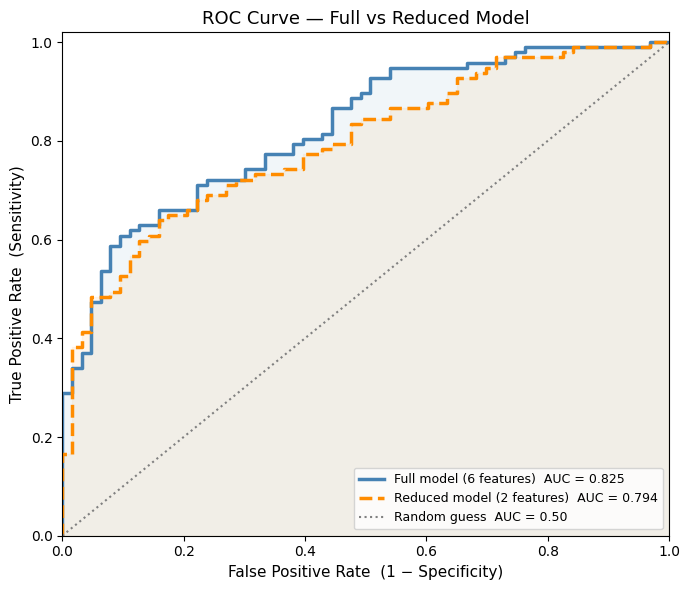

Full model AUC    : 0.8246
Reduced model AUC : 0.7943
AUC difference    : +0.0303  → Full model is better


In [17]:
def roc_curve_manual(y_true, y_prob):
    thresholds = np.sort(np.unique(y_prob))[::-1]
    tprs, fprs = [0.], [0.]
    for t in thresholds:
        yp = (y_prob >= t).astype(int)
        m  = classification_metrics(y_true, yp)
        tprs.append(m['sensitivity'])
        fprs.append(m['fpr'])
    tprs.append(1.); fprs.append(1.)
    return np.array(fprs), np.array(tprs)

def auc_trapezoid(fpr, tpr):
    """AUC via the trapezoidal rule."""
    idx = np.argsort(fpr)
    return np.trapezoid(tpr[idx], fpr[idx])

# ── Train reduced model (only 2 features) ─────────────────────────────────────
feat_idx_reduced = [feature_cols.index('glucose'), feature_cols.index('bmi')]
X_train_reduced  = add_intercept(X_train[:, feat_idx_reduced])
X_test_reduced   = add_intercept(X_test[:,  feat_idx_reduced])

beta_reduced, _ = logistic_fit(X_train_reduced, y_train, lr=0.1, epochs=2000)
y_prob_reduced  = predict_proba(X_test_reduced, beta_reduced)

# ── ROC curves ────────────────────────────────────────────────────────────────
fpr_full,    tpr_full    = roc_curve_manual(y_test, y_pred_prob)
fpr_reduced, tpr_reduced = roc_curve_manual(y_test, y_prob_reduced)

auc_full    = auc_trapezoid(fpr_full,    tpr_full)
auc_reduced = auc_trapezoid(fpr_reduced, tpr_reduced)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_full,    tpr_full,    color='steelblue',    linewidth=2.5,
        label=f'Full model (6 features)  AUC = {auc_full:.3f}')
ax.plot(fpr_reduced, tpr_reduced, color='darkorange',   linewidth=2.5, linestyle='--',
        label=f'Reduced model (2 features)  AUC = {auc_reduced:.3f}')
ax.plot([0,1],[0,1], color='gray', linestyle=':', linewidth=1.5, label='Random guess  AUC = 0.50')

ax.fill_between(fpr_full, tpr_full, alpha=0.07, color='steelblue')
ax.fill_between(fpr_reduced, tpr_reduced, alpha=0.07, color='darkorange')

ax.set_xlabel("False Positive Rate  (1 − Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate  (Sensitivity)", fontsize=11)
ax.set_title("ROC Curve — Full vs Reduced Model", fontsize=13)
ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
plt.tight_layout(); plt.show()

print(f"Full model AUC    : {auc_full:.4f}")
print(f"Reduced model AUC : {auc_reduced:.4f}")
print(f"AUC difference    : {auc_full - auc_reduced:+.4f}  → Full model is better")


## 13 · Precision-Recall Curve — When to Use It

**Why not just use ROC/AUC?**  
ROC is optimistic when classes are **imbalanced**. A model that predicts "not diabetic"  
for everyone gets a great TN rate, inflating the ROC.

**Precision-Recall (PR) curve** focuses on the **positive class** only:
- X-axis: **Recall** (sensitivity) — how many positives we catch
- Y-axis: **Precision** — of those we flag, how many are truly positive

**Average Precision (AP)** = area under the PR curve (analogous to AUC).

**When to prefer PR over ROC:**
- Class imbalance (rare disease, fraud detection)
- The cost of false positives is high (unnecessary treatment)
- You care more about performance on the minority class


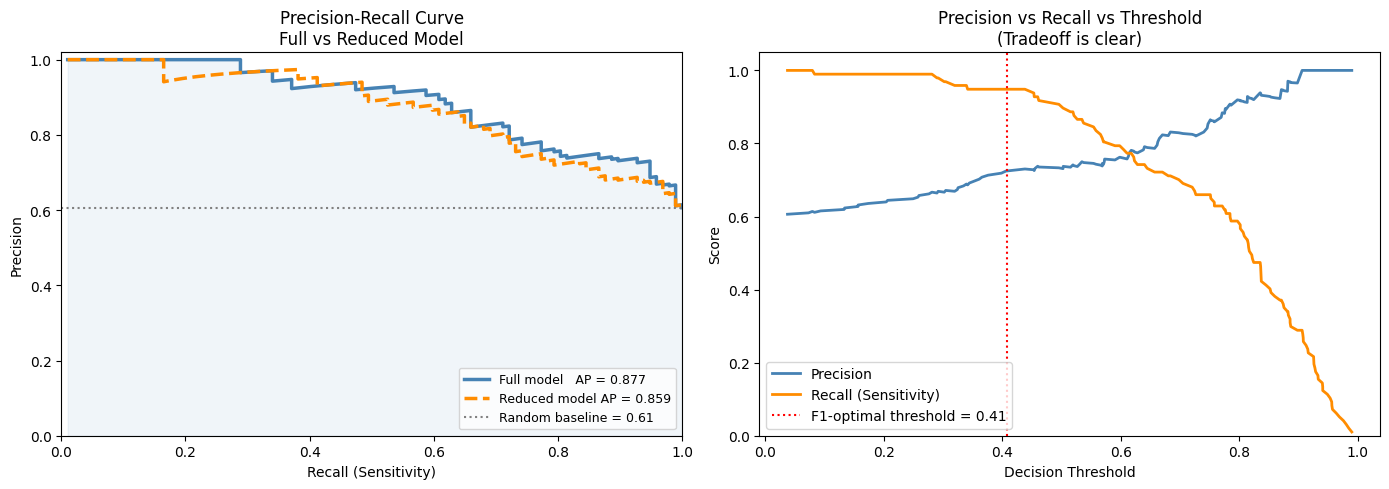


💡 When recall rises (lower threshold), precision tends to fall — the tradeoff.
   Use PR when your dataset is imbalanced (here: 61% positive).


In [14]:
def pr_curve_manual(y_true, y_prob):
    thresholds = np.sort(np.unique(y_prob))[::-1]
    precisions, recalls = [], []
    for t in thresholds:
        yp = (y_prob >= t).astype(int)
        m  = classification_metrics(y_true, yp)
        precisions.append(m['precision'])
        recalls.append(m['sensitivity'])
    return np.array(recalls), np.array(precisions)

recall_full,    prec_full    = pr_curve_manual(y_test, y_pred_prob)
recall_reduced, prec_reduced = pr_curve_manual(y_test, y_prob_reduced)

# Average precision (area under PR curve)
def avg_precision(recall, precision):
    idx = np.argsort(recall)
    return np.trapezoid(precision[idx], recall[idx])

ap_full    = avg_precision(recall_full,    prec_full)
ap_reduced = avg_precision(recall_reduced, prec_reduced)

# Baseline = random classifier = prevalence
baseline_precision = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PR curve
axes[0].plot(recall_full,    prec_full,    color='steelblue',  linewidth=2.5,
             label=f'Full model   AP = {ap_full:.3f}')
axes[0].plot(recall_reduced, prec_reduced, color='darkorange', linewidth=2.5, linestyle='--',
             label=f'Reduced model AP = {ap_reduced:.3f}')
axes[0].axhline(baseline_precision, color='gray', linestyle=':', linewidth=1.5,
                label=f'Random baseline = {baseline_precision:.2f}')
axes[0].fill_between(recall_full, prec_full, alpha=0.08, color='steelblue')
axes[0].set_xlabel("Recall (Sensitivity)"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve\nFull vs Reduced Model")
axes[0].legend(fontsize=9); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.02)

# Right: Precision & Recall vs threshold
thresholds_plot = np.sort(np.unique(y_pred_prob))[::-1]
prec_t, rec_t = [], []
for t in thresholds_plot:
    yp = (y_pred_prob >= t).astype(int)
    m  = classification_metrics(y_test, yp)
    prec_t.append(m['precision'])
    rec_t.append(m['sensitivity'])

axes[1].plot(thresholds_plot, prec_t, color='steelblue',   linewidth=2, label='Precision')
axes[1].plot(thresholds_plot, rec_t,  color='darkorange',  linewidth=2, label='Recall (Sensitivity)')
axes[1].axvline(best_t_f1, color='red', linestyle=':', linewidth=1.5,
                label=f'F1-optimal threshold = {best_t_f1:.2f}')
axes[1].set_xlabel("Decision Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Precision vs Recall vs Threshold\n(Tradeoff is clear)")
axes[1].legend(); axes[1].set_ylim(0, 1.05)

plt.tight_layout(); plt.show()

print("\n💡 When recall rises (lower threshold), precision tends to fall — the tradeoff.")
print(f"   Use PR when your dataset is imbalanced (here: {y_test.mean():.0%} positive).")


## 14 · Final Model Summary Dashboard

In [15]:
# ── Metrics at default threshold and Youden threshold ─────────────────────────
m_default = classification_metrics(y_test, (y_pred_prob >= 0.50).astype(int))
m_youden  = classification_metrics(y_test, (y_pred_prob >= best_t_youden).astype(int))
m_f1opt   = classification_metrics(y_test, (y_pred_prob >= best_t_f1).astype(int))

print("═" * 62)
print(f"  {'Metric':<22} {'t=0.50':>10} {'Youden t':>10} {'F1-opt t':>10}")
print("═" * 62)
for key, label in [('accuracy','Accuracy'), ('sensitivity','Sensitivity'),
                   ('specificity','Specificity'), ('precision','Precision'), ('f1','F1')]:
    print(f"  {label:<22} {m_default[key]:>10.4f} {m_youden[key]:>10.4f} {m_f1opt[key]:>10.4f}")
print("─" * 62)
print(f"  {'Threshold':<22} {'0.500':>10} {best_t_youden:>10.3f} {best_t_f1:>10.3f}")
print(f"  {'AUC (full model)':<22} {auc_full:>10.4f}")
print(f"  {'AUC (reduced)':<22} {auc_reduced:>10.4f}")
print(f"  {'McFadden R²':<22} {mcfadden_r2:>10.4f}")
print("═" * 62)
print()
print("Key takeaways:")
print("  • AUC is threshold-free → best for comparing models overall")
print("  • Sensitivity/Recall matters when missing a positive is costly (disease, fraud)")
print("  • Precision matters when false alarms are costly (spam filter, legal review)")
print("  • Youden threshold balances sensitivity + specificity")
print("  • PR curve > ROC when classes are heavily imbalanced")
print("  • RFE identifies which features actually drive predictions")
print("  • High VIF → multicollinearity → unstable coefficients & p-values")


══════════════════════════════════════════════════════════════
  Metric                     t=0.50   Youden t   F1-opt t
══════════════════════════════════════════════════════════════
  Accuracy                   0.7375     0.7250     0.7562
  Sensitivity                0.8969     0.6082     0.9485
  Specificity                0.4921     0.9048     0.4603
  Precision                  0.7311     0.9077     0.7302
  F1                         0.8056     0.7284     0.8251
──────────────────────────────────────────────────────────────
  Threshold                   0.500      0.778      0.409
  AUC (full model)           0.8246
  AUC (reduced)              0.7943
  McFadden R²                0.2298
══════════════════════════════════════════════════════════════

Key takeaways:
  • AUC is threshold-free → best for comparing models overall
  • Sensitivity/Recall matters when missing a positive is costly (disease, fraud)
  • Precision matters when false alarms are costly (spam filter, legal rev

## 15 · Cheat Sheet

```
LOGISTIC REGRESSION
  Model        : p = σ(Xβ)  where σ(z) = 1/(1+e⁻ᶻ)
  Loss         : Binary Cross-Entropy = −mean[y·log(p) + (1−y)·log(1−p)]
  Fit          : Gradient descent on loss  →  β ← β − α · Xᵀ(p̂−y)/n
  No closed form (unlike OLS), but convex → guaranteed global minimum

P-VALUES (Wald Test)
  SE(β)  via Fisher Information: (XᵀWX)⁻¹, W=p(1−p)
  z = β/SE  →  p = 2·(1 − Φ(|z|))

PSEUDO R²
  McFadden: 1 − LL_full/LL_null   (0.2–0.4 = good for logistic)

VIF
  VIF_j = 1/(1−R²_j)   >5 = worry, >10 = serious

RFE
  Train → drop smallest |coef| → retrain → repeat

CONFUSION MATRIX METRICS
  Accuracy    = (TP+TN) / total
  Sensitivity = TP / (TP+FN)   ← don't miss sick people
  Specificity = TN / (TN+FP)   ← don't alarm healthy people
  Precision   = TP / (TP+FP)   ← trust positive predictions
  F1          = 2·P·R / (P+R)  ← balanced score
  Youden      = Sensitivity + Specificity − 1  (optimal threshold)

ROC / AUC
  AUC = P(model ranks random + above random −)
  1.0 = perfect, 0.5 = random, compare models without fixing threshold

PRECISION-RECALL
  Use when classes are imbalanced or cost of FP is high
  Average Precision = area under PR curve
```
